### Implement Ridge Regression, fit the model and evaluate.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the dataset from the file Ecommerce.csv

```
This dataset includes the following data for 200 online customers:

- Email
- Adress
- Avatar
- Avg Session Length (everage time they spent on usage)
- Time on App (time they spent using the application)
- Time on Website (time they spent using the website)
- Length of Membership (for how long they have been a user)
- Yearly Amount Spent (how much money they spend yearly)

Yout goal will be to estimate the value of the Yearly Amount Spent using the feature(s) of the users
```

In [ ]:
df=pd.read_csv('Ecommerce.csv')
df.head()

,Email,Address,Avatar,Avg Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg Session Length    500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


### Get rid of non-numerical columns of the dataset

In [ ]:
df_numeric = df.select_dtypes(include=np.number)
df_numeric.head()

,Avg Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


### Use Yearly Amount Spent as your target variable. Plot the relationship of each of the numerical features with the target variable

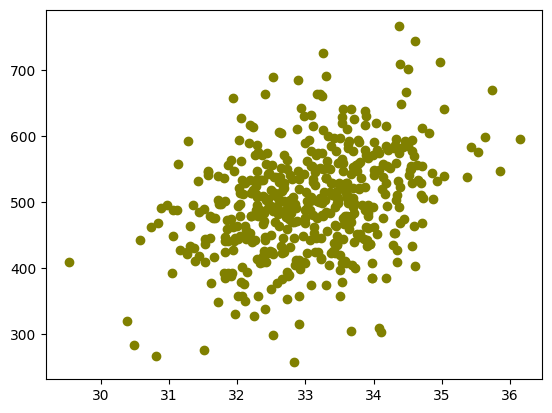

In [ ]:
plt.scatter(df_numeric['Avg Session Length'], df_numeric['Yearly Amount Spent'], c="olive")

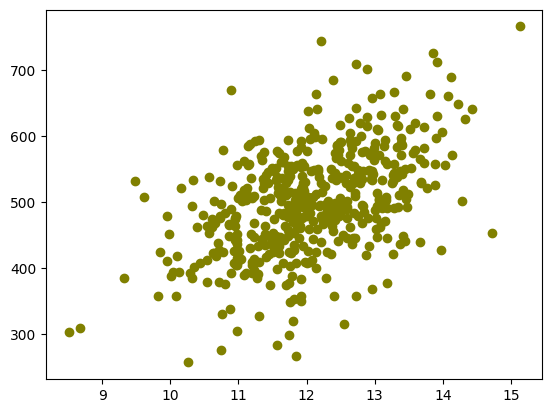

In [ ]:
plt.scatter(df_numeric['Time on App'], df_numeric['Yearly Amount Spent'],c="olive")

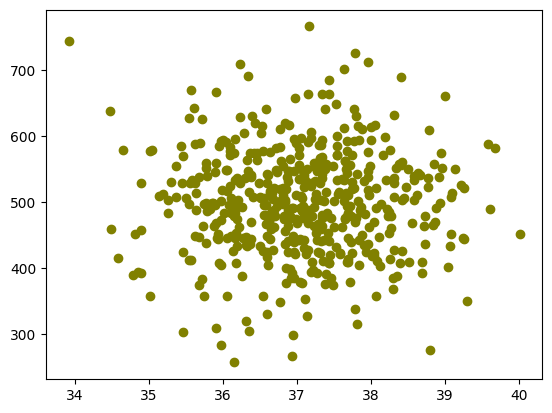

In [ ]:
plt.scatter(df_numeric['Time on Website'], df_numeric['Yearly Amount Spent'],c='olive')

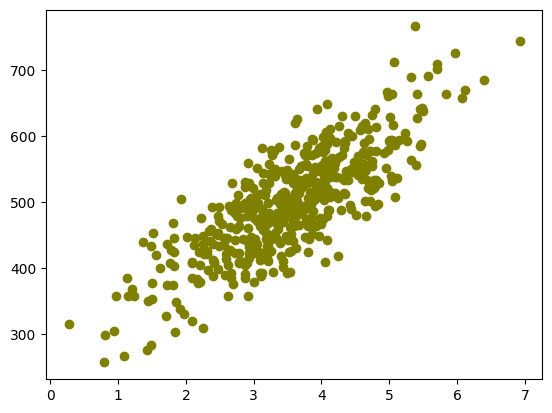

In [ ]:
plt.scatter(df_numeric['Length of Membership'], df_numeric['Yearly Amount Spent'],c="olive")

from these 4 scatter plots we can say that the between "Length of Membership" and "Yearly Amount Spent" ther is linear relationship. So I'm going to keep only this feature for our further analysis

### Leave only one feature that has a linear relationship with the target variable.

In [ ]:
new_df = df_numeric[['Length of Membership', 'Yearly Amount Spent']]
new_df.head()

,Length of Membership,Yearly Amount Spent
0,4.082621,587.951054
1,2.664034,392.204933
2,4.104543,487.547505
3,3.120179,581.852344
4,4.446308,599.406092


### Divide the dataset into training and test sets with the ratio 80:20.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(new_df['Length of Membership'], new_df['Yearly Amount Spent'], test_size=0.2, random_state=42)

### Use the resulting train and test sets with the next 2 functions to fit linear regression and plot the resulting regression line.

The first function is `fit_1d_linear_regression` that takes two vectors $x$ and $y$, and returns a numpy array ($\beta_0, \beta_1)$, where $\beta_0$ is the intercept of the line, and $\beta_1$ is the slope.

In [ ]:
def fit_1d_linear_regression(data_vector, response_vector):
    """
    :param data_vector: A pandas series object (i.e. a column of a dataframe),
                        where each element is a data point (x)
    :param response_vector: A pandas series object (i.e. a column of a dataframe),
                        where each element is label (y)
    :return: numpy array beta of coefficients of the regression
    Note: You can avoid the intercept for simplicity
    """
    x=np.array(data_vector)
    y=np.array(response_vector)

    x_mean=np.mean(x)
    y_mean=np.mean(y)

    numerator=np.sum((x-x_mean)*(y-y_mean))
    denominator=np.sum((x-x_mean)**2)
    if denominator==0:
        raise ValueError("denominator is zero")
    beta_1=numerator/denominator
    beta_0=y_mean-beta_1*x_mean
    print(beta_0, beta_1)

    return np.array([beta_0, beta_1])

The second function is `plot_line` function, that takes $\beta_0, \beta_1, x, y$ and plots a scatter plot of the data, and the line $y = \beta_0 + \beta_1 x$. And saves the plot in `YOURNAME.png`

In [ ]:
def plot_fitted_line(b0: float,
                     b1: float,
                     x,
                     y,
                     username: str):
    """
    :param b0: Intersept of line to plot
    Note: avoid this if you don't have an intercept in the previous function
    :param b1: Slope of the line to plot
    :param x: A pandas series object (i.e. a column of a dataframe),
                        where each element is a data point (x coordinates)
    :param y: A pandas series object (i.e. a column of a dataframe),
                        where each element is a label (y coordinates)
    """


import numpy as np
import matplotlib.pyplot as plt

def plot_fitted_line(b0: float,
                     b1: float,
                     x,
                     y,
                     username: str):
    """
    :param b0: Intercept of line to plot
    :param b1: Slope of the line to plot
    :param x: pandas Series of x values
    :param y: pandas Series of y values
    :param username: Name to show in the plot title
    """
    x_vals = x.to_numpy()
    y_vals = y.to_numpy()
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_line = b0 + b1 * x_line  # fitted line

    plt.figure(figsize=(8, 6))
    plt.scatter(x_vals, y_vals, label="Data points", c=['violet','olive'])
    plt.plot(x_line, y_line, label="Fitted line", linewidth=2)

    plt.xlabel(x.name if x.name is not None else "x")
    plt.ylabel(y.name if y.name is not None else "y")
    plt.title(f"Fitted Linear Regression Line ({username})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Plot example

**bold text**![image.png](attachment:image.png)

### Now fit the linear regression to the data containing only 1 feature using sklearn and compare the results with your own fit_1d_linear_regression function

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

resault = fit_1d_linear_regression(X_train, y_train)   # [b0, b1]
resalut1 = LinearRegression().fit(X_train.values.reshape(-1, 1), y_train)


b0_custom, b1_custom = resault[0], resault[1]
b0_sklearn = resalut1.intercept_
b1_sklearn = resalut1.coef_[0]

print("Custom intercept:", b0_custom)
print("Custom slope    :", b1_custom)
print("sklearn intercept:", b0_sklearn)
print("sklearn slope    :", b1_sklearn)
print("diff intercept   :", b0_custom - b0_sklearn)
print("diff slope       :", b1_custom - b1_sklearn)

y_pred_custom = b0_custom + b1_custom * X_train
y_pred_sklearn = resalut1.predict(X_train.values.reshape(-1, 1))



271.35211280339325 64.64010065386707
Custom intercept: 271.35211280339325
Custom slope    : 64.64010065386707
sklearn intercept: 271.3521128033932
sklearn slope    : 64.64010065386708
diff intercept   : 5.684341886080802e-14
diff slope       : -1.4210854715202004e-14


### Use sklearn.metrics to calculate Mean absolute error, Mean squared error, Root mean squared error and R-squared for the results of your own function vs the sklearn regression results. Try to interprete your results.

In [ ]:

def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R^2 :", r2)


print_metrics("Custom regression", y_train, y_pred_custom)
print_metrics("sklearn regression", y_train, y_pred_sklearn)



Custom regression
MAE : 37.326107702427855
MSE : 2170.445239710518
RMSE: 46.588037517269576
R^2 : 0.6698451495121833

sklearn regression
MAE : 37.326107702427855
MSE : 2170.445239710518
RMSE: 46.588037517269576
R^2 : 0.6698451495121833


### Fit linear regression to the data containing all numerical features using sklearn and use the same metrics to evaluate how good the model is.

In [ ]:

X = df_numeric.drop('Yearly Amount Spent', axis=1)
y = df_numeric['Yearly Amount Spent']
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (500, 4)
Shape of y: (500,)


In [ ]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X1_train, y1_train)

y1_train_pred = model.predict(X1_train)
y1_test_pred = model.predict(X1_test)

print("Model with all numerical features:")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

print_metrics("Train set (all features)", y1_train, y1_train_pred)
print_metrics("Test set (all features)", y1_test, y1_test_pred)

Model with all numerical features:
Intercept: -1044.257414636555
Coefficients: [25.5962591  38.78534598  0.31038593 61.89682859]

Train set (all features)
MAE : 7.727000731099066
MSE : 95.82253022867229
RMSE: 9.788898315370954
R^2 : 0.9854240629700333

Test set (all features)
MAE : 8.558441885315247
MSE : 109.86374118394066
RMSE: 10.481590584636507
R^2 : 0.9778130629184125


### Evaluate model with K-fold cross-validation.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

rmse_scores = np.sqrt(-cv_scores)

print("K-fold Cross-Validation RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Standard deviation of RMSE:", rmse_scores.std())

K-fold Cross-Validation RMSE scores: [10.48159058  9.55706134 10.2307194   9.92141001  9.80539436]
Mean RMSE: 9.999235138918074
Standard deviation of RMSE: 0.3241605811109878


### Implement Ridge Regression, fit the model and evaluate.

In [ ]:
from sklearn.linear_model import Ridge

def fit_1d_ridge_regression(data_vector, response_vector, lmb=1):
    """
    :param data_vector: A pandas series object (i.e. a column of a dataframe),
                        where each element is a data point (x)
    :param response_vector: A pandas series object (i.e. a column of a dataframe),
                        where each element is label (y)
    :param lmb: The regularization parameter (lambda)
    :return: numpy array beta of coefficients of the regression
    """
    x = np.array(data_vector)
    y = np.array(response_vector)

    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_centered = x - x_mean
    y_centered = y - y_mean

    numerator = np.sum(x_centered * y_centered)
    denominator = np.sum(x_centered**2) + lmb

    if denominator == 0:
        raise ValueError("Denominator is zero, cannot compute beta_1.")

    beta_1 = numerator / denominator
    beta_0 = y_mean - beta_1 * x_mean

    return np.array([beta_0, beta_1])


In [ ]:

X_train_1f, X_test_1f, y_train_1f, y_test_1f = train_test_split(
    new_df['Length of Membership'], new_df['Yearly Amount Spent'], test_size=0.2, random_state=42
)

lmb_value = 1.0

b0_ridge_custom, b1_ridge_custom = fit_1d_ridge_regression(X_train_1f, y_train_1f, lmb=lmb_value)

y_pred_ridge_custom_train = b0_ridge_custom + b1_ridge_custom * X_train_1f
y_pred_ridge_custom_test = b0_ridge_custom + b1_ridge_custom * X_test_1f

print(f"\nCustom Ridge Regression (lambda={lmb_value}):")
print(f"Intercept (beta_0): {b0_ridge_custom}")
print(f"Slope (beta_1): {b1_ridge_custom}")

print_metrics("Custom Ridge Regression (Train)", y_train_1f, y_pred_ridge_custom_train)
print_metrics("Custom Ridge Regression (Test)", y_test_1f, y_pred_ridge_custom_test)

ridge_sklearn = Ridge(alpha=lmb_value)
ridge_sklearn.fit(X_train_1f.values.reshape(-1, 1), y_train_1f)

y_pred_ridge_sklearn_train = ridge_sklearn.predict(X_train_1f.values.reshape(-1, 1))
y_pred_ridge_sklearn_test = ridge_sklearn.predict(X_test_1f.values.reshape(-1, 1))

print(f"\nScikit-learn Ridge Regression (alpha={lmb_value}):")
print(f"Intercept: {ridge_sklearn.intercept_}")
print(f"Coefficient: {ridge_sklearn.coef_[0]}")

print_metrics("Sklearn Ridge Regression (Train)", y_train_1f, y_pred_ridge_sklearn_train)
print_metrics("Sklearn Ridge Regression (Test)", y_test_1f, y_pred_ridge_sklearn_test)


Custom Ridge Regression (lambda=1.0):
Intercept (beta_0): 271.8979262209063
Slope (beta_1): 64.48712880002225

Custom Ridge Regression (Train)
MAE : 37.31531498083064
MSE : 2170.4699014996227
RMSE: 46.58830219593351
R^2 : 0.6698413981117123

Custom Ridge Regression (Test)
MAE : 37.82135777245869
MSE : 2161.510658840825
RMSE: 46.4920494153659
R^2 : 0.5634838166616867

Scikit-learn Ridge Regression (alpha=1.0):
Intercept: 271.89792622090636
Coefficient: 64.48712880002223

Sklearn Ridge Regression (Train)
MAE : 37.31531498083064
MSE : 2170.469901499622
RMSE: 46.5883021959335
R^2 : 0.6698413981117124

Sklearn Ridge Regression (Test)
MAE : 37.821357772458676
MSE : 2161.510658840825
RMSE: 46.4920494153659
R^2 : 0.5634838166616867


### Implement Lasso regression, fit the model and evaluate.

NOTE: In 1-D, LASSO has a closed form: it takes the ordinary least-squares solution and shrinks it towards zero. If the shrinkage is large enough, it becomes exactly zero.

In [ ]:
def fit_1d_lasso_regression(data_vector, response_vector, lmb=1):
    """
    :param data_vector: A pandas series object (i.e. a column of a dataframe),
                        where each element is a data point (x)
    :param response_vector: A pandas series object (i.e. a column of a dataframe),
                        where each element is label (y)
    :param lmb: The regularization parameter (lambda)
    :return: numpy array beta of coefficients of the regression
    """
    x = np.array(data_vector)
    y = np.array(response_vector)

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    x_centered = x - x_mean
    y_centered = y - y_mean

    numerator_ols = np.sum(x_centered * y_centered)
    denominator_ols = np.sum(x_centered**2)

    if denominator_ols == 0:
        beta_1 = 0.0
    else:

        threshold = lmb / 2
        if numerator_ols > threshold:
            beta_1 = (numerator_ols - threshold) / denominator_ols
        elif numerator_ols < -threshold:
            beta_1 = (numerator_ols + threshold) / denominator_ols
        else:
            beta_1 = 0.0

    beta_0 = y_mean - beta_1 * x_mean

    return np.array([beta_0, beta_1])

In [ ]:
from sklearn.linear_model import Lasso

lmb_lasso_value = 0.5
b0_lasso_custom, b1_lasso_custom = fit_1d_lasso_regression(X_train_1f, y_train_1f, lmb=lmb_lasso_value)

y_pred_lasso_custom_train = b0_lasso_custom + b1_lasso_custom * X_train_1f
y_pred_lasso_custom_test = b0_lasso_custom + b1_lasso_custom * X_test_1f

print(f"\nCustom Lasso Regression (lambda={lmb_lasso_value}):")
print(f"  Intercept (beta_0): {b0_lasso_custom}")
print(f"  Slope (beta_1): {b1_lasso_custom}")

print_metrics("Custom Lasso Regression (Train)", y_train_1f, y_pred_lasso_custom_train)
print_metrics("Custom Lasso Regression (Test)", y_test_1f, y_pred_lasso_custom_test)

lasso_sklearn = Lasso(alpha=lmb_lasso_value, random_state=42)
lasso_sklearn.fit(X_train_1f.values.reshape(-1, 1), y_train_1f)

y_pred_lasso_sklearn_train = lasso_sklearn.predict(X_train_1f.values.reshape(-1, 1))
y_pred_lasso_sklearn_test = lasso_sklearn.predict(X_test_1f.values.reshape(-1, 1))

print(f"\nScikit-learn Lasso Regression (alpha={lmb_lasso_value}):")
print(f"  Intercept: {lasso_sklearn.intercept_}")
print(f"  Coefficient: {lasso_sklearn.coef_[0]}")

print_metrics("Sklearn Lasso Regression (Train)", y_train_1f, y_pred_lasso_sklearn_train)
print_metrics("Sklearn Lasso Regression (Test)", y_test_1f, y_pred_lasso_sklearn_test)


Custom Lasso Regression (lambda=0.5):
  Intercept (beta_0): 271.3542287815259
  Slope (beta_1): 64.63950762136318

Custom Lasso Regression (Train)
MAE : 37.32606586182417
MSE : 2170.445240081164
RMSE: 46.588037521247486
R^2 : 0.669845149455803

Custom Lasso Regression (Test)
MAE : 37.836176229413624
MSE : 2162.109233088251
RMSE: 46.49848635265724
R^2 : 0.5633629348400484

Scikit-learn Lasso Regression (alpha=0.5):
  Intercept: 273.0448953095137
  Coefficient: 64.16567465075192

Sklearn Lasso Regression (Train)
MAE : 37.29618227764828
MSE : 2170.6824527120757
RMSE: 46.59058330512804
R^2 : 0.6698090661217202

Sklearn Lasso Regression (Test)
MAE : 37.79009716529534
MSE : 2160.3656872072575
RMSE: 46.47973415594432
R^2 : 0.5637150432094121
